# Очистка данных. Практическая работа

## Цель практической работы

- Научиться выполнять очистку и подготовку данных для их дальнейшего использования в задаче машинного обучения.

## Что нужно сделать

- Загрузить данные в ноутбук.
- Провести разведочный анализ данных.
- Разделить данные на обучающую и тестовую выборки.
- Выполнить очистку и подготовку данных.

## Что оценивается 

1. Выполнены все этапы задания.
1. Не допущены утечки данных.

## Формат сдачи

Выполните предложенные задания: впишите свой код в ячейки после комментария `### YOUR CODE HERE ###` и сохраните изменения, используя опцию *Save and Checkpoint* из вкладки меню *File* или кнопку *Save and Checkpoint* на панели инструментов. Итоговый файл в формате `.ipynb` (файл Jupyter Notebook) загрузите в личный кабинет и отправьте на проверку.

## Задача
Имеется набор данных покупателей супермаркета. Проведите анализ и очистку этих данных.

### Описание данных

Дан файл Mall_Customers.csv, содержащий следующие данные по покупателям сети супермаркетов:
- CustomerID — идентификатор покупателя.
- Genre – пол покупателя.
- Age – возраст покупателя.
- Annual Income (k\$) – годовой доход покупателя, тысяч $.
- Spending Score (1–100) – рейтинг покупателя, целевая переменная.

### Задание 1

Загрузите данные из файла `Mall_Customers.csv` в ноутбук и выведите первые пять строк на экран.

In [1]:
### YOUR CODE HERE ###
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19.0,15.0,39
1,2,Male,NaN,NaN,81
2,3,Female,NaN,16.0,6
3,4,Female,23.0,16.0,77
4,5,Female,31.0,17.0,40


### Задание 2

Проведите разведочный анализ загруженных данных. Обязательные атрибуты для анализа:
- количество пропусков в каждом признаке;
- распределения признаков;
- возможные выбросы или аномалии.

Анализ дополнительных атрибутов и свойств данных приветствуется. Используйте средства визуализации там, где это необходимо.

По результатам анализа сделайте выводы о свойствах отдельных признаков и качестве данных в целом.

<Axes: >

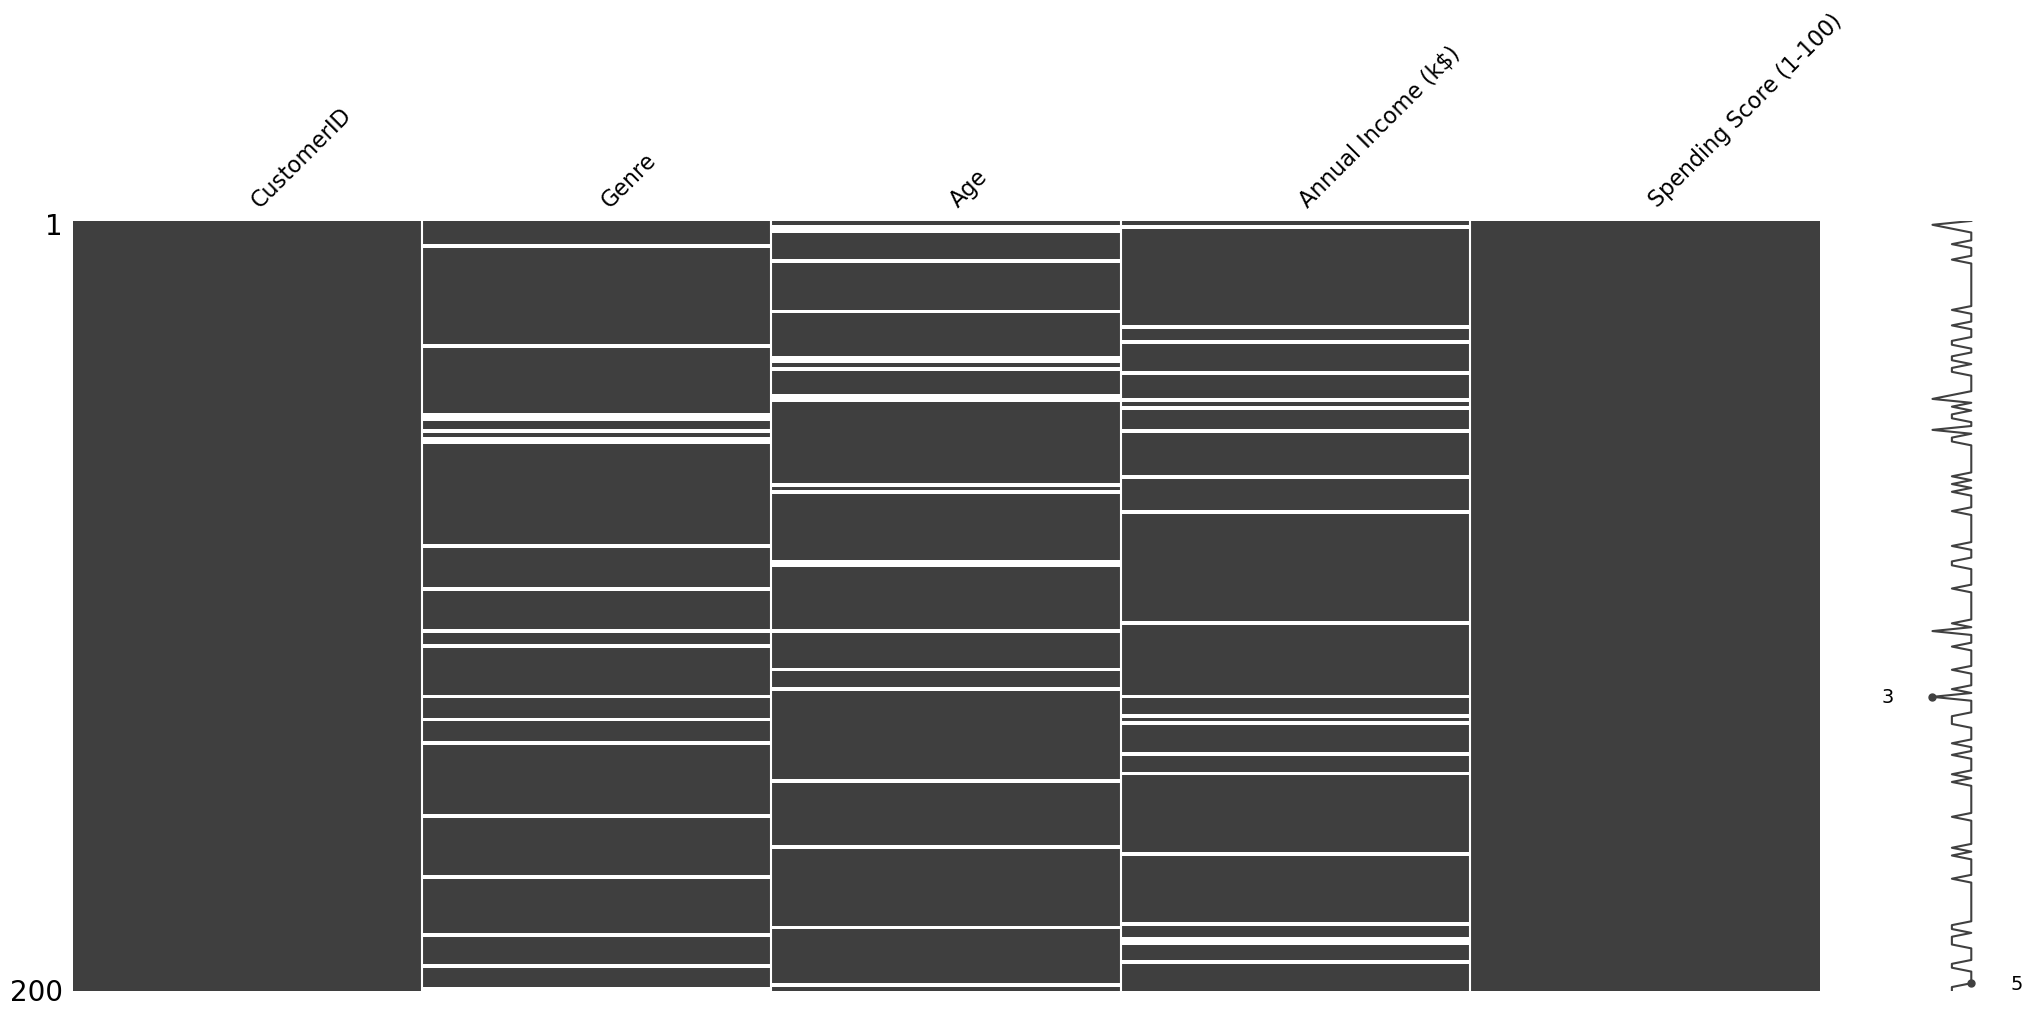

In [3]:
### YOUR CODE HERE ###
msno.matrix(df)

In [4]:
df = df.drop(['CustomerID'], axis=1)

In [5]:
#смотрим количество пропусков
df.isna().sum()

Genre                     19
Age                       20
Annual Income (k$)        20
Spending Score (1-100)     0
dtype: int64

In [6]:
# рпопуски в процентах
df.isna().sum() / df.shape[0]

Genre                     0.095
Age                       0.100
Annual Income (k$)        0.100
Spending Score (1-100)    0.000
dtype: float64

In [7]:
print(df.dtypes)

Genre                      object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)      int64
dtype: object


In [8]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,180.000000,180.000000,200.000000
mean,39.894444,5615.433333,50.200000
std,16.842848,74531.115872,25.823522
min,18.000000,15.000000,1.000000
25%,29.000000,42.000000,34.750000
50%,36.000000,61.000000,50.000000
75%,49.000000,78.000000,73.000000
max,135.000000,1000000.000000,99.000000


Histogram for Age


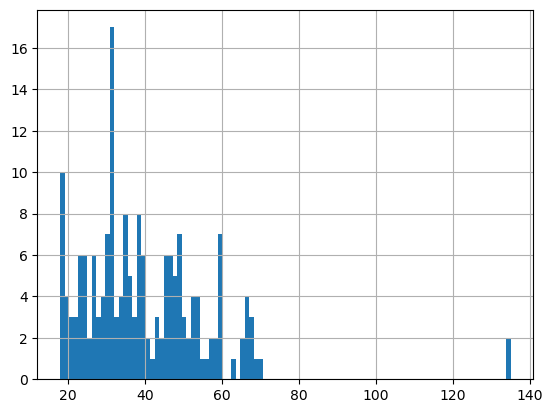

Histogram for Annual Income (k$)


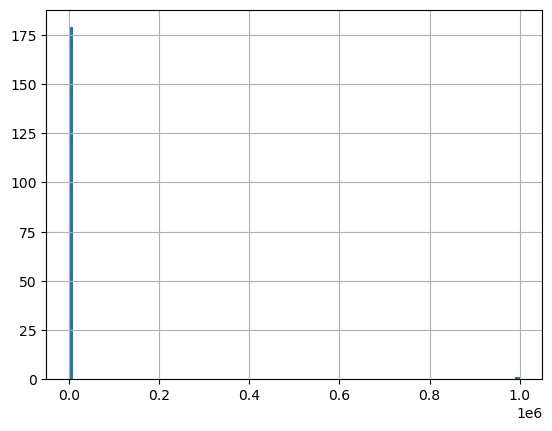

Histogram for Spending Score (1-100)


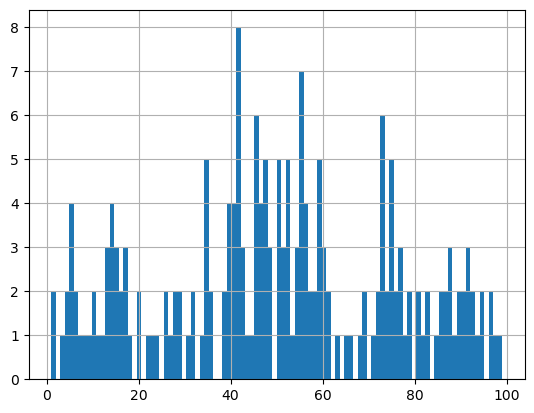

In [9]:
# распределения признаков
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_features:
  print(f'Histogram for {col}')
  df[col].hist(bins=100)
  plt.show()

<Axes: >

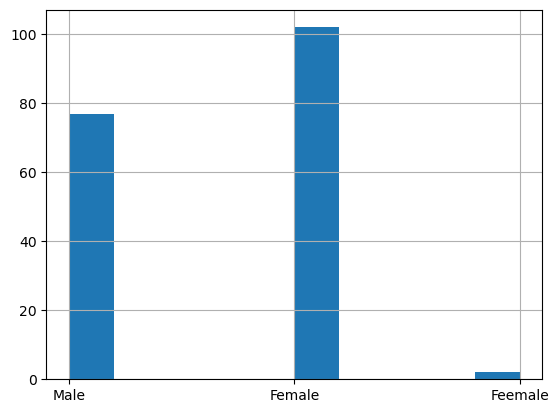

In [10]:
df['Genre'].hist()

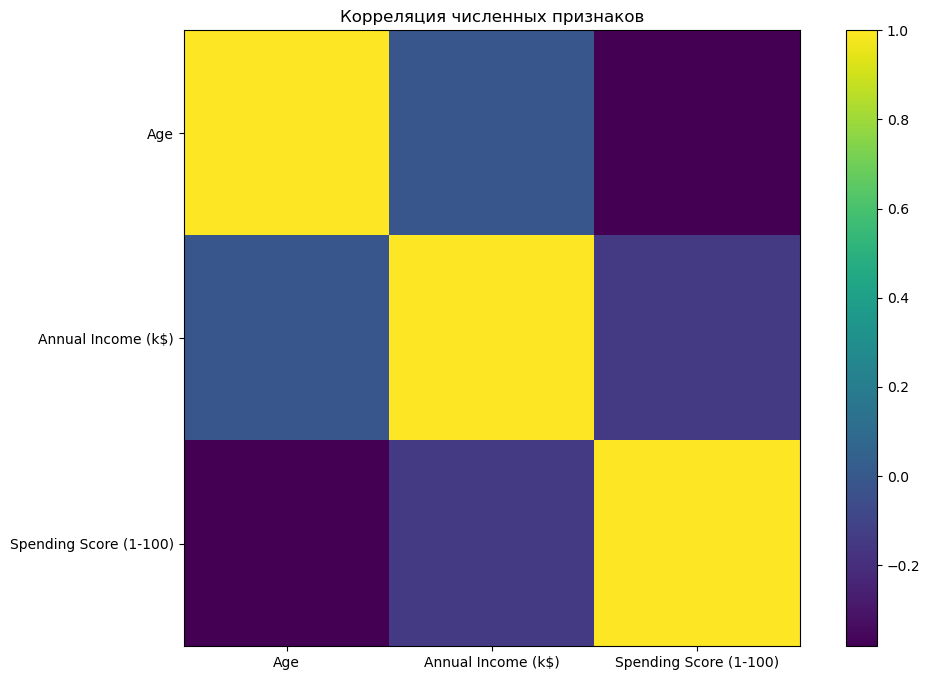

In [11]:
plt.figure(figsize=(12, 8))

columns = df.corr().columns.tolist()
plt.imshow(df.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

### Задание 3

Разделите данные на обучающую и тестовую выборки в пропорции 80:20. Здесь и далее используйте random_state = 1.

In [12]:
### YOUR CODE HERE ###
y = df['Spending Score (1-100)']
X = df.drop(['Spending Score (1-100)'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### Задание 4

Заполните пропуски в признаках в обучающей выборке с использованием инструментов sklearn. Для каждого признака выберите и аргументируйте стратегию заполнения пропусков.

In [13]:
### YOUR CODE HERE ###


In [14]:
#Заполним пропуски признаков 'Age' и 'Annual Income (k$)' медианой, т.к. она устойчива к аномалиям и выбросам
imp_median = SimpleImputer(strategy='median')

med_cols = ['Age', 'Annual Income (k$)']

X_train[med_cols] = imp_median.fit_transform(X_train[med_cols])
X_train.head()


,Genre,Age,Annual Income (k$)
108,Male,68.0,63.0
107,Male,54.0,63.0
189,Female,36.0,103.0
14,Male,37.0,20.0
56,NaN,51.0,44.0


In [15]:
#Заполним пропуски категориальных признаков 'Genre' самым популярным значением
imp_moda = SimpleImputer(strategy='most_frequent')

cat_cols = ['Genre']

X_train[cat_cols] = imp_moda.fit_transform(X_train[cat_cols])

X_train.head()

,Genre,Age,Annual Income (k$)
108,Male,68.0,63.0
107,Male,54.0,63.0
189,Female,36.0,103.0
14,Male,37.0,20.0
56,Female,51.0,44.0


<Axes: >

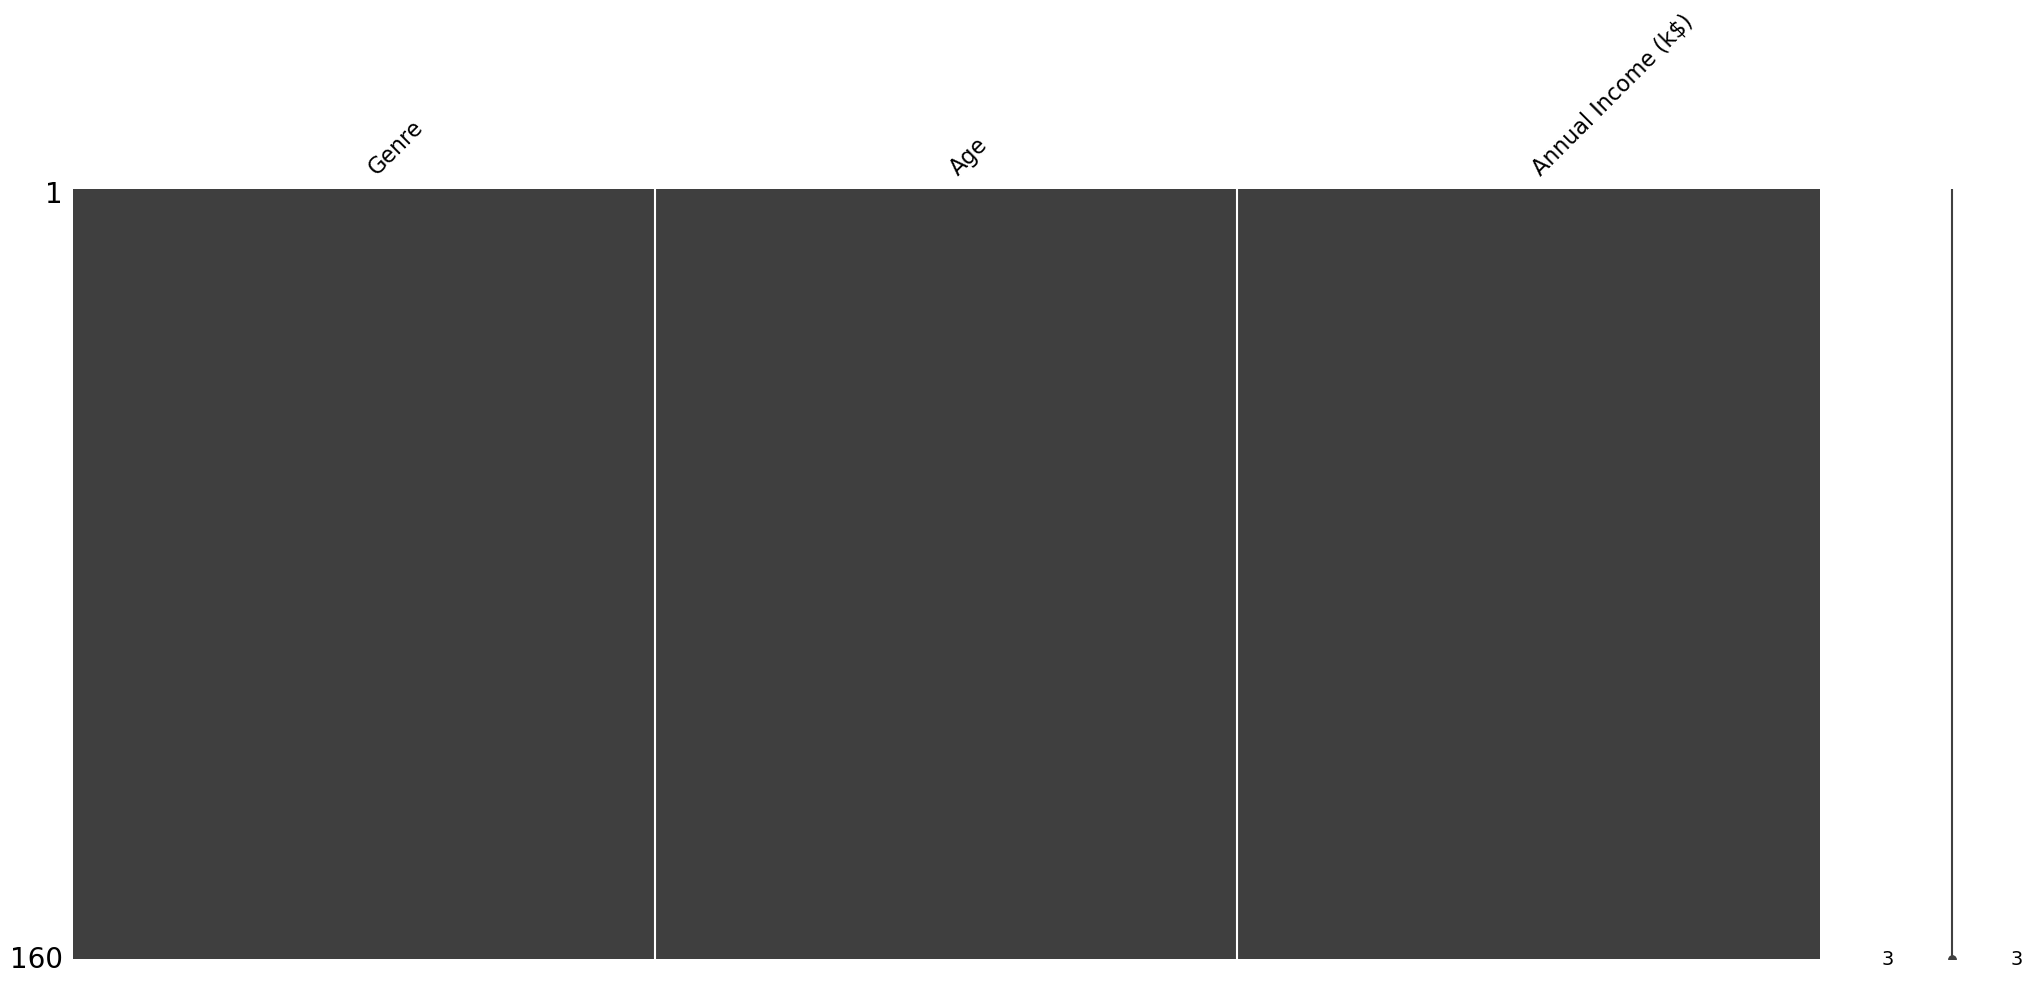

In [16]:
#еще раз проверим на наличое пропусков
msno.matrix(X_train)

### Задание 5

Найдите выбросы в признаках обучающей выборки. Замените выбросы, если таковые имеются, и аргументируйте выбор метода поиска выбросов.


In [17]:
### YOUR CODE HERE ###


In [18]:
#Посмотрим на наличие выбросов в признаках 'Age', 'Annual Income (k$)' при помощи визуализации

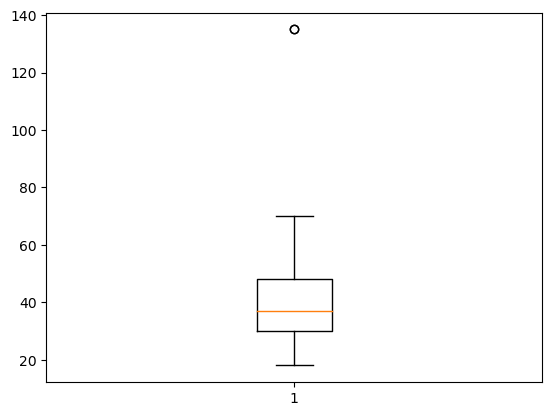

In [19]:
plt.boxplot(X_train.Age)
plt.show()

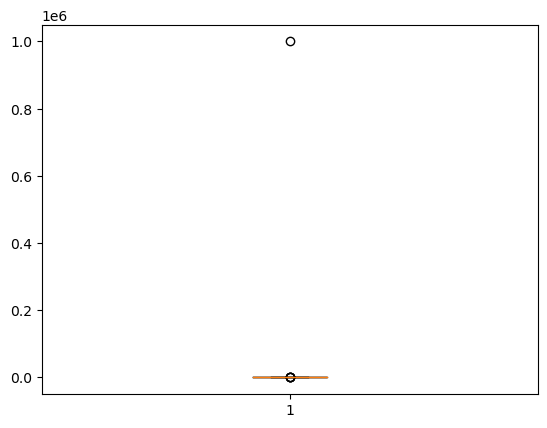

In [20]:
plt.boxplot(X_train['Annual Income (k$)'])
plt.show()

In [21]:
#Определим значения выбросов с помощью метода межквартильного расстояния

In [22]:
def calculate_iqr_boundaries(series):
  q25 = series.quantile(0.25)
  q75 = series.quantile(0.75)
  iqr = q75 - q25

  boundaries = (q25 - 1.5 * iqr, q75 + 1.5 * iqr)
  return boundaries

In [23]:
age_bounds = calculate_iqr_boundaries(X_train['Age'])
income_bounds = calculate_iqr_boundaries(X_train['Annual Income (k$)'])

In [24]:
X_train = X_train[(X_train['Age'] >= age_bounds[0]) & (X_train['Age'] <= age_bounds[1])]
X_train = X_train[(X_train['Annual Income (k$)'] >= income_bounds[0]) & (X_train['Annual Income (k$)'] <= income_bounds[1])]

### Задание 6

Нормализуйте численные признаки. Аргументируйте выбор стратегии нормализации для каждого признака.


In [25]:
### YOUR CODE HERE ###


In [26]:
#Нормализуем численные признаки с помощью StandardScaler, т.к. MinMaxScaler более чувствителен к выбросам и аномалиям, которые могут присутствовать в выборке

In [27]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train[['Age', 'Annual Income (k$)']])
X_train_s = pd.DataFrame(X_train_s, columns=['Age', 'Annual Income (k$)'])
X_train_s

,Age,Annual Income (k$)
0,2.244147,0.193085
1,1.181365,0.193085
2,-0.185069,2.092893
3,-0.109156,-1.849208
4,0.953626,-0.709324
...,...,...
148,-0.564634,0.620542
149,-0.488721,0.668037
150,1.636843,-0.424353
151,1.409104,0.763027


### Задание 7

Закодируйте категориальные признаки в обучающей выборке. Аргументируйте выбор способа кодирования.

In [28]:
### YOUR CODE HERE ###


In [29]:
#т.к. в признаке 'Genre' всего два значения, то заменим 'Male' на 1, а 'Female' на 0 чтобы не было линейной зависимости, 
#одновременно избавляемся от неправильно заполненных знвчений типа 'Feemale'

In [30]:
X_train = X_train.reset_index(drop=True)
X_train_s['Genre'] = X_train['Genre'].apply(lambda x: 1.0 if x == 'Male' else 0.0).fillna(0)


### Задание 8
Проведите очистку и подготовку тестовых данных. Используйте препроцессоры и другие инструменты, которые вы уже использовали при подготовке обучающей выборки, без их дополнительной настройки.

In [31]:
### YOUR CODE HERE ###


In [32]:
X_test[med_cols] = imp_median.transform(X_test[med_cols])

X_test[cat_cols] = imp_moda.transform(X_test[cat_cols])

age_bounds = calculate_iqr_boundaries(X_test['Age'])
income_bounds = calculate_iqr_boundaries(X_test['Annual Income (k$)'])
X_test = X_test[(X_test['Age'] >= age_bounds[0]) & (X_test['Age'] <= age_bounds[1])]
X_test = X_test[(X_test['Annual Income (k$)'] >= income_bounds[0]) & (X_test['Annual Income (k$)'] <= income_bounds[1])]

X_test_s = scaler.transform(X_test[['Age', 'Annual Income (k$)']])
X_test_s = pd.DataFrame(X_test_s, columns=['Age', 'Annual Income (k$)'])

X_test = X_test.reset_index(drop=True)
X_test_s['Genre'] = X_test['Genre'].apply(lambda x: 1.0 if x == 'Male' else 0.0).fillna(0)

In [33]:
X_test_s

,Age,Annual Income (k$),Genre
0,-0.868286,-0.614333,0.0
1,2.016408,-0.994295,0.0
2,0.801800,-1.231771,0.0
3,2.168234,0.145590,1.0
4,0.194496,1.902912,0.0
5,-0.109156,3.707730,1.0
6,-1.096025,0.050599,0.0
7,-0.564634,-1.991694,0.0
8,-1.171938,-1.421752,0.0
9,-0.185069,1.332970,0.0
